In [73]:
# import classy module
from classy import Class

In [74]:
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
# LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
LambdaCDM.set({'output':'tCl,pCl,lCl,mPknw','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0})

# run class
LambdaCDM.compute()

# get reduced Hubble for conversions to 1/Mpc
h = LambdaCDM.h()


In [75]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from math import pi
from matplotlib import rc
from matplotlib import rcParams
import numpy as np
from plotting_utils import plot_segments, plot_compare

# Enable LaTeX rendering
rcParams['figure.dpi'] = 120
rc('text', usetex=True)
rc('font', family='serif', size=13)

rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
})

In [76]:
# Don't use IR resummed powerspectra (yet)
use_IR_resum = 1
test_run_idx = 8

works_arr = [1, 1, 1, 1, 1, 1, 0]
dir = "/Users/fynn/Desktop/Uni/Master/Masters-thesis/Dennis_data/"
file_names = ["Bell_z0p95_NoIR_b1_s1.txt", "Bell_z0p95_NoIR_b1_s2.txt", "Bell_z0p95_NoIR_b1_s3.txt",
              "Bell_z0p95_NoIR_b1.txt", "Bell_z0p95_NoIR_b2.txt", "Bell_z0p95_NoIR_bG2.txt",
              "Bell_z0p95_NoIR.txt", "Bell_z0p95_IR.txt", "Bell_z0p95_corrected_noise_IR_resum_new_WnW.txt"]
b1_arr  = [1., 1., 1., 1., 0., 0., 1.5, 1.5, 1.5]
b2_arr  = [0., 0., 0., 0., 1., 0., -1., -1., -1.]
bG2_arr = [0., 0., 0., 0., 0., 1., -0.35, -0.35, -0.35]
d1_arr  = [0., 0., 1., 0., 0., 0., 1., 1., 1.]
d2_arr  = [0.5, 0., 0., 0., 0., 0., 0.5, 0.5, 0.5]
d3_arr  = [0., 1., 0., 0., 0., 0., 1., 1., 1.]

data_file_name = dir+file_names[test_run_idx]
data_file_name1 = dir+file_names[8]
b1 = b1_arr[test_run_idx]
b2 = b2_arr[test_run_idx]
bG2 = bG2_arr[test_run_idx]
d1 = d1_arr[test_run_idx]
d2 = d2_arr[test_run_idx]
d3 = d3_arr[test_run_idx]

# noise bias:
n_bar = 0.000779126064152255*h**3  # Unit conversion since Dennis uses 
P_eps = 1./n_bar

z = 0.95

In [77]:
read_mode = ""   # other modes are: "squeezed" (k1=k2=5*k3), "squeezed_2" (k1=k1, k3=kf) or "" (read all triangles)
n_rows = 5130
limit_low = 0
limit_up  = 5000

n_triag = np.arange(limit_low, limit_up)
B0_Dennis, B2_Dennis, B4_Dennis, B0_Fynn, B2_Fynn, B4_Fynn, k1_arr, k2_arr, k3_arr = LambdaCDM.bispectrum_comparison_Dennis(data_file_name, limit_low, limit_up, use_IR_resum, b1, b2, bG2, d1, d2, d3, P_eps, z, read_mode)

n_triag = n_triag[B0_Dennis!=0]

k1_arr = k1_arr[B0_Dennis!=0]
k2_arr = k2_arr[B0_Dennis!=0]
k3_arr = k3_arr[B0_Dennis!=0]

B0_Fynn = B0_Fynn[B0_Dennis!=0]
B2_Fynn = B2_Fynn[B0_Dennis!=0]
B4_Fynn = B4_Fynn[B0_Dennis!=0]

B2_Dennis = B2_Dennis[B0_Dennis!=0]
B4_Dennis = B4_Dennis[B0_Dennis!=0]
B0_Dennis = B0_Dennis[B0_Dennis!=0]




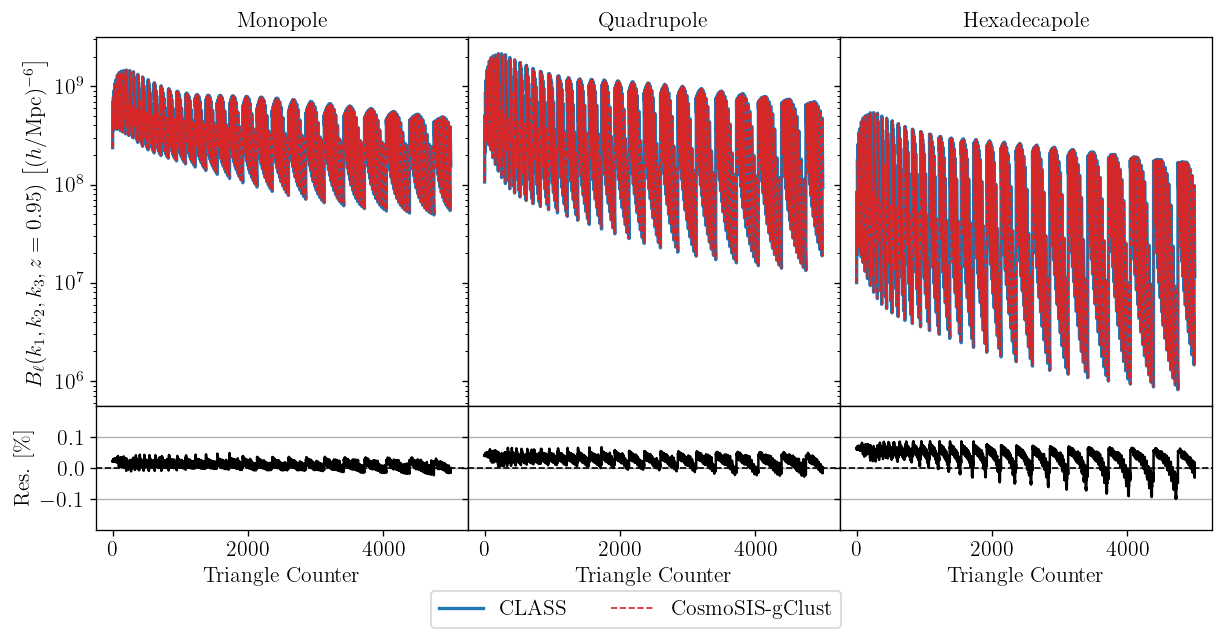

Your bias parameters:
b1=1.5, b2=-1.0, bG2=-0.35, d1=1.0, d2=0.5, d3=1.0
data file name: /Users/fynn/Desktop/Uni/Master/Masters-thesis/Dennis_data/Bell_z0p95_corrected_noise_IR_resum_new_WnW.txt


In [78]:
colors = ["tab:blue", "tab:red",  "tab:green"]
mode = ["lin", "log"]
ylabel = rf"$B_\ell(k_1, k_2, k_3, z={z})$ $\left[(h/\mathrm{{Mpc}})^{{-6}}\right]$"
xlabel = "Triangle Counter"
sharexy = True
abs_rel_mode = "rel"

plot_compare(n_triag, B0_Fynn*h**6, B0_Dennis*h**6, B2_Fynn*h**6, B2_Dennis*h**6, B4_Fynn*h**6, B4_Dennis*h**6, xlabel, ylabel,"CLASS", "CosmoSIS-gClust", ["Monopole", "Quadrupole", "Hexadecapole"], "Vergleich_all", colors, mode, abs_rel_mode, sharexy)
#plot_compare(n_triag, B2_Fynn, B2_Dennis, z,"l=2 Fynn", "l=2 Dennis", f"Quadrupole,   b1={b1}, b2={b2}, bG2={bG2}, d1={d1}, d2={d2}, d3={d3}", "Vergleich_l2", colors, mode)
#plot_compare(n_triag, B4_Fynn, B4_Dennis, z,"l=4 Fynn", "l=4 Dennis", f"Hexadecapole, b1={b1}, b2={b2}, bG2={bG2}, d1={d1}, d2={d2}, d3={d3}", "Vergleich_l4", colors, mode)

print("Your bias parameters:")
print(f"b1={b1}, b2={b2}, bG2={bG2}, d1={d1}, d2={d2}, d3={d3}")
print(f"data file name: {data_file_name}")

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/var/folders/1t/6lvnjwb12mq1gyh7dlscmql00000gn/T/ipykernel_73350/2063447831.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$k [h/\mathrm{{Mpc}})]$")


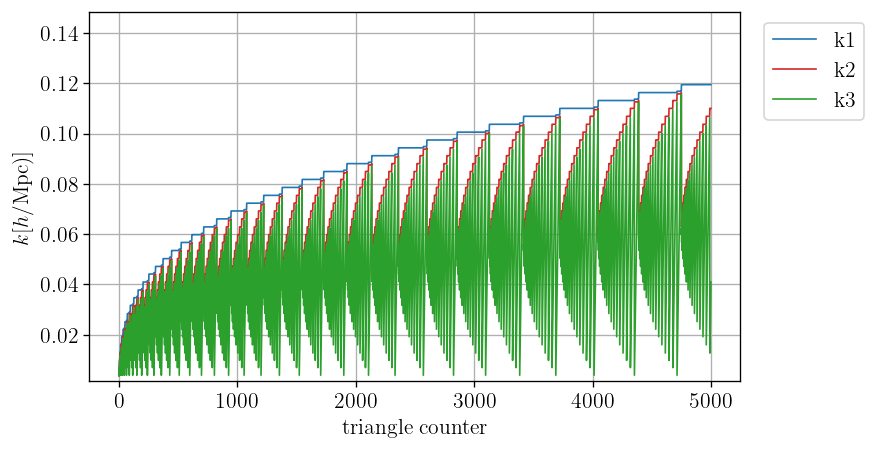

k_min= 0.004442883 0.0036621089999999998 0.0036621089999999998
k_max= 0.11944289999999999 0.1162971 0.1155087


In [ ]:
# k-space
plt.figure(figsize=(7, 4))
plt.plot(n_triag, (k1_arr/h), linewidth=1, color=colors[0], label="k1")
plt.plot(n_triag, (k2_arr/h), linewidth=1, color=colors[1], label="k2")
plt.plot(n_triag, (k3_arr/h), linewidth=1, color=colors[2], label="k3")

#plt.yscale("log")
#plt.xscale("log")
plt.ylim(1e-3/h, 0.1/h)

plt.xlabel("triangle counter")
plt.ylabel("$k [h/\mathrm{{Mpc}}]$")
plt.grid()
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1))  # Moves legend outside
plt.savefig("bispectrum_comp_k_range.pdf", bbox_inches="tight")
plt.show()

print("k_min=", min(k1_arr/h), min(k2_arr/h), min(k3_arr/h))
print("k_max=", max(k1_arr/h), max(k2_arr/h), max(k3_arr/h))

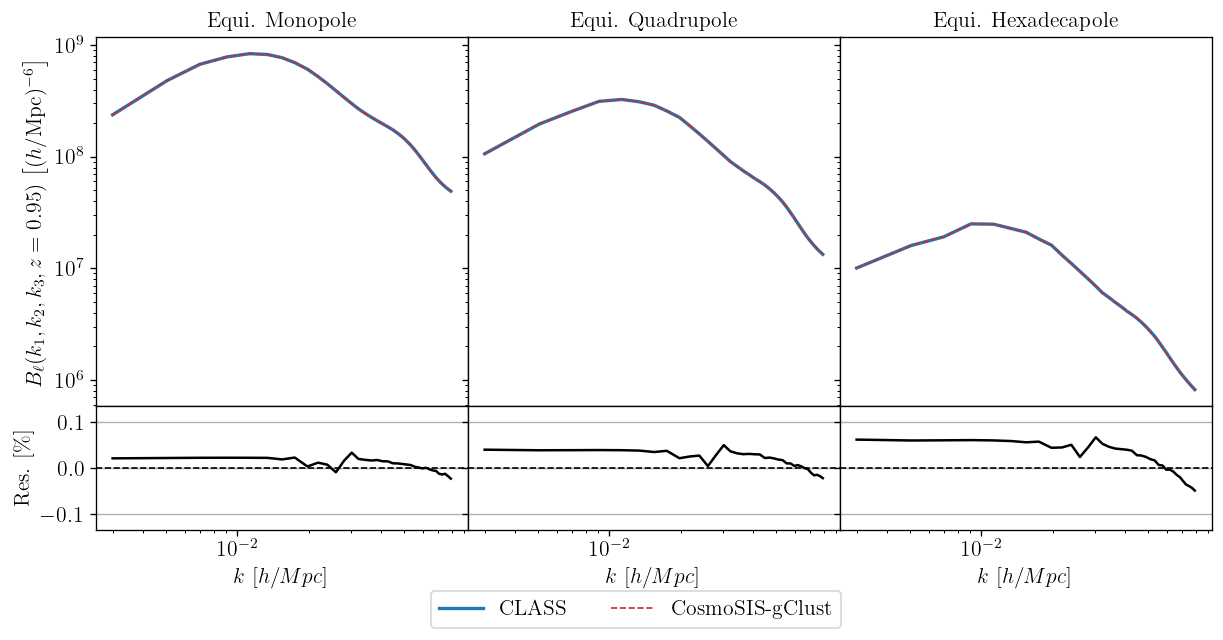

In [80]:
read_mode = "equi"   # other modes are: "equi" k1=k2=k3, "squeezed" (k1=k2=5*k3), "squeezed_2" (k1=k1, k3=kf) or "" (read all triangles)
n_rows = 5130
limit_low = 0
limit_up  = 5050

n_triag = np.arange(limit_low, limit_up)
B0_Dennis, B2_Dennis, B4_Dennis, B0_Fynn, B2_Fynn, B4_Fynn, k1_arr, k2_arr, k3_arr = LambdaCDM.bispectrum_comparison_Dennis(data_file_name, limit_low, limit_up, use_IR_resum, b1, b2, bG2, d1, d2, d3, P_eps, z, read_mode)

n_triag = n_triag[B0_Dennis!=0]

k1_arr = k1_arr[B0_Dennis!=0]
k2_arr = k2_arr[B0_Dennis!=0]
k3_arr = k3_arr[B0_Dennis!=0]

B0_Fynn = B0_Fynn[B0_Dennis!=0]
B2_Fynn = B2_Fynn[B0_Dennis!=0]
B4_Fynn = B4_Fynn[B0_Dennis!=0]

B2_Dennis = B2_Dennis[B0_Dennis!=0]
B4_Dennis = B4_Dennis[B0_Dennis!=0]
B0_Dennis = B0_Dennis[B0_Dennis!=0]

mode = mode = ["log", "log"]
ylabel = rf"$B_\ell(k_1, k_2, k_3, z={z})$ $\left[(h/\mathrm{{Mpc}})^{{-6}}\right]$"
xlabel = rf"$k$ $[h/Mpc]$"
sharexy = True
abs_rel_mode = "rel"
plot_compare(k1_arr, B0_Fynn*h**6, B0_Dennis*h**6, B2_Fynn*h**6, B2_Dennis*h**6, B4_Fynn*h**6, B4_Dennis*h**6, xlabel, ylabel,"CLASS", "CosmoSIS-gClust", ["Equi. Monopole", "Equi. Quadrupole", "Equi. Hexadecapole"], "Vergleich_equi", colors, mode, abs_rel_mode, sharexy)


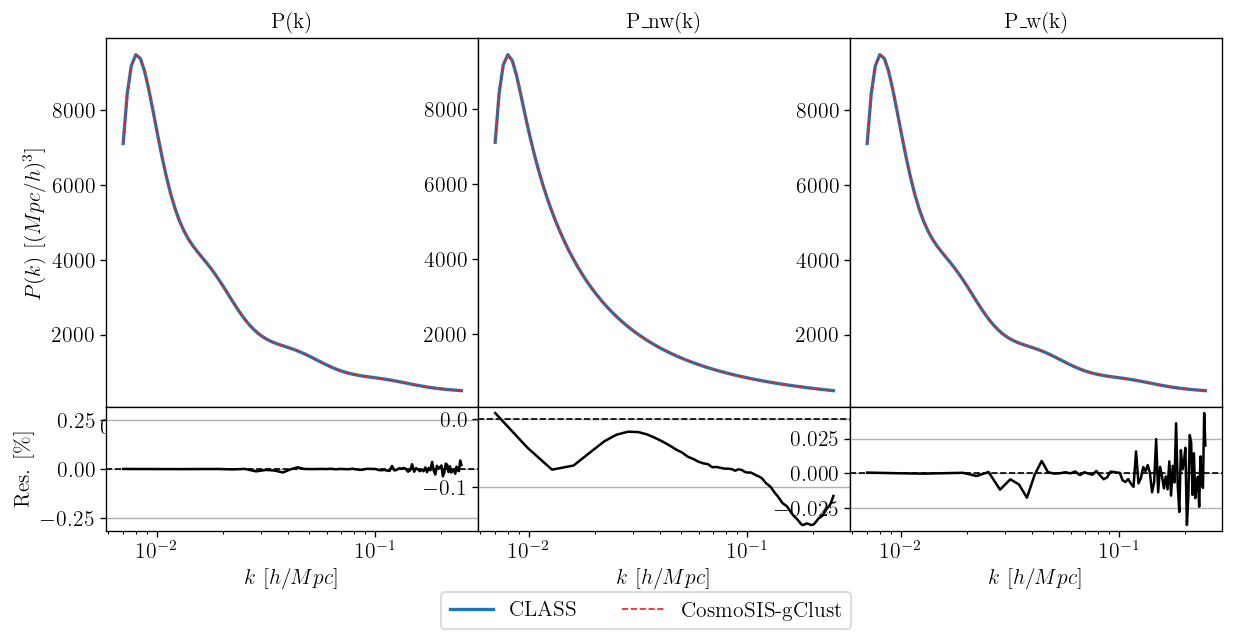

In [81]:
limit_low = 3
limit_up  = 81
data_file_name = dir+"P_wnw_z0p95.txt"
data_file_name1 = dir+"P_wnw_z0p95_new.txt"
ylabel = rf"$P(k)$ $[(Mpc/h)^3]$"
xlabel = rf"$k$ $[h/Mpc]$"
mode = ["log", "lin"]
sharexy = False
abs_rel_mode = "rel"


P_Dennis, P_nw_Dennis, P_w_Dennis, P_Fynn, P_nw_Fynn, P_w_Fynn, k_arr = LambdaCDM.P_wiggle_nowiggle_comparison_Dennis(data_file_name, limit_low, limit_up, z)
P_Dennis1, P_nw_Dennis1, P_w_Dennis1, P_Fynn, P_nw_Fynn, P_w_Fynn, k_arr = LambdaCDM.P_wiggle_nowiggle_comparison_Dennis(data_file_name1, limit_low, limit_up, z)



plot_compare(k_arr/h, P_Fynn*h**3, P_Dennis*h**3, P_nw_Fynn*h**3, P_nw_Dennis*h**3, P_Fynn*h**3, P_Dennis*h**3, xlabel, ylabel, "CLASS", "CosmoSIS-gClust", ["P(k)", "P_nw(k)", "P_w(k)"], "Vergleich_wiggle_powerspectra_all", colors, mode, abs_rel_mode, sharexy)



In [82]:
# P1_Dennis, P2_Dennis, P3_Dennis, P1_Fynn, P2_Fynn, P3_Fynn, k1_arr, k2_arr, k3_arr = LambdaCDM.powerspectrum_comparison_Dennis(data_file_name, limit_low, limit_up, z)

#do_plots(n_triag, P1_Fynn, P1_Dennis, z, "P1 Fynn", "P1 Dennis", "Powerspectrum", "Vergleich_p1_Dennis_Fynn")
#do_plots(n_triag, P2_Fynn, P2_Dennis, z, "P2 Fynn", "P2 Dennis", "Powerspectrum", "Vergleich_p2_Dennis_Fynn")
#do_plots(n_triag, P3_Fynn, P3_Dennis, z, "P3 Fynn", "P3 Dennis", "Powerspectrum", "Vergleich_p3_Dennis_Fynn")